<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>Ensemble</h2>
    <hr>
    <h4>1. StackingClassifier (BalancedRandomForest, CatBoostClassifier, RandomForestClassifier), DecisionTree </h4>
    <h4>2. VotingClassifier   (BalancedRandomForest, CatBoostClassifier, RandomForestClassifier) </h4>
</div>

In [33]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [34]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [36]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [37]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [40]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [41]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
        ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', MinMaxScaler())
        ])  
)

In [42]:
X_train = transformer.fit_transform(X_train)

In [43]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. Stacking</h2>
</div>

In [44]:
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>XGBClassifier</h4>    
</div>

In [45]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', 
                          eval_metric=make_scorer(fbeta_score, beta=2, pos_label=1),
                          enable_categorical=True,
                          random_state=42)

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>CatBoostClassifier</h4>    
</div>

In [46]:
cat_model = CatBoostClassifier(
    class_weights={0:1, 1:9}, 
    random_state=42, 
    verbose=False,
    l2_leaf_reg=10,
    eval_metric = 'Precision')

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>BalancedRandomForestClassifier</h4>    
</div>

In [47]:
brf_model = BalancedRandomForestClassifier(
     n_estimators= 15,
     class_weight='balanced',
     random_state=42,
     sampling_strategy='auto',
     replacement=True,
     n_jobs=-1
)

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>RandomForestClassifier</h4>    
</div>

In [48]:
rf_model = RandomForestClassifier(ccp_alpha=0.001, 
                                  class_weight='balanced',
                                  max_samples=0.8, 
                                  n_jobs=-1, 
                                  random_state=42,
                                  verbose=False)

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>DecisionTreeClassifier</h4>    
</div>

In [49]:
dtree_model = DecisionTreeClassifier(class_weight={0: 1, 1: 9},min_samples_split=0.0001, random_state=42)

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>LogisticRegression</h4>    
</div>

In [50]:
lr_model = LogisticRegression()

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h3>--> StackingClassifier</h3>
</div>

In [51]:
stacking_model = StackingClassifier(
    estimators=[
				('brf', brf_model), 
				('cat', cat_model),
				('rf', rf_model)
			],
    final_estimator=dtree_model,  
    passthrough=True  
)

In [52]:
stacking_model.fit(X_train, y_train)

StackingClassifier(estimators=[('brf',
                                BalancedRandomForestClassifier(class_weight='balanced',
                                                               n_estimators=15,
                                                               n_jobs=-1,
                                                               random_state=42,
                                                               sampling_strategy='auto')),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7fcc22ccd190>),
                               ('rf',
                                RandomForestClassifier(ccp_alpha=0.001,
                                                       class_weight='balanced',
                                                       max_samples=0.8,
                                                       n_jobs=-1,
                                                       random_state=42,
                                                       verbose=False))],
                   final_estimator=DecisionTreeClassifier(class_weight={0: 1,
                                                                        1: 9},
                                                          min_samples_split=0.0001,
                                                          random_state=42),
                   passthrough=True)

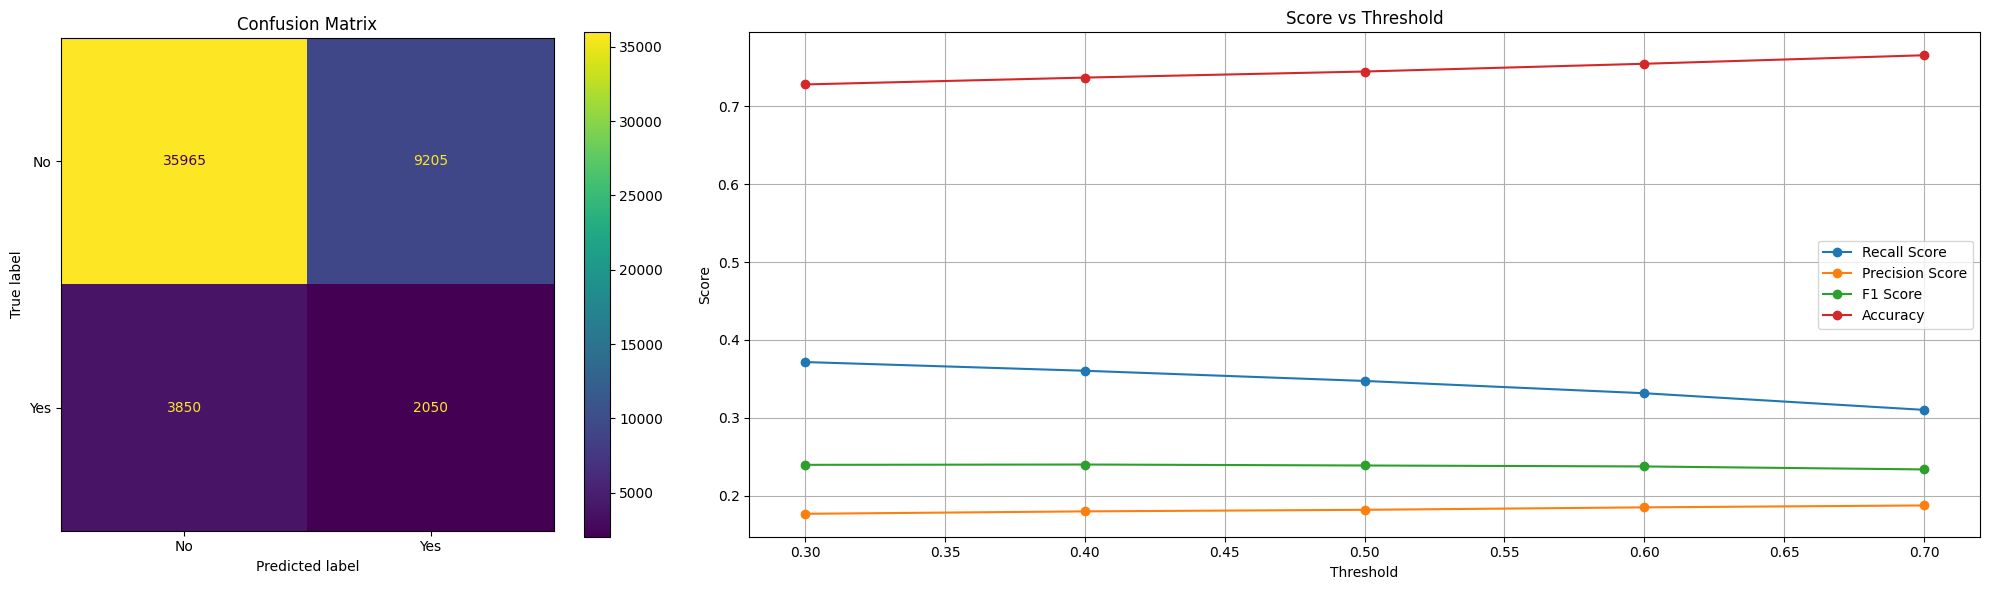

,Score,Percentage
0,Training Accuracy,79.30%
1,Test Accuracy,74.44%
2,Recall Score,34.75%
3,Precision Score,18.21%
4,Accuracy Score,74.44%
5,F1 Score,23.90%
6,ROC AUC Score,57.18%


In [53]:
scores_df, threshold_df = print_evaluation(stacking_model, X_train, y_train, X_test, y_test)
scores_df

In [54]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.372,0.177,0.240,0.728
0.400,0.361,0.180,0.240,0.737
0.500,0.347,0.182,0.239,0.744
0.600,0.332,0.185,0.238,0.754
0.700,0.310,0.188,0.234,0.765


<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h3>--> VotingClassifier</h3>
</div>

In [55]:
from sklearn.ensemble import VotingClassifier

In [56]:
soft_voter = VotingClassifier([
				('brf', brf_model), 
				('cat', cat_model),
				('rf', rf_model)
			], voting = 'soft')

In [57]:
soft_voter.fit(X_train, y_train)

VotingClassifier(estimators=[('brf',
                              BalancedRandomForestClassifier(class_weight='balanced',
                                                             n_estimators=15,
                                                             n_jobs=-1,
                                                             random_state=42,
                                                             sampling_strategy='auto')),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7fcc22ccd190>),
                             ('rf',
                              RandomForestClassifier(ccp_alpha=0.001,
                                                     class_weight='balanced',
                                                     max_samples=0.8, n_jobs=-1,
                                                     random_state=42,
                                                     verbose=False))],
                 voting='soft')

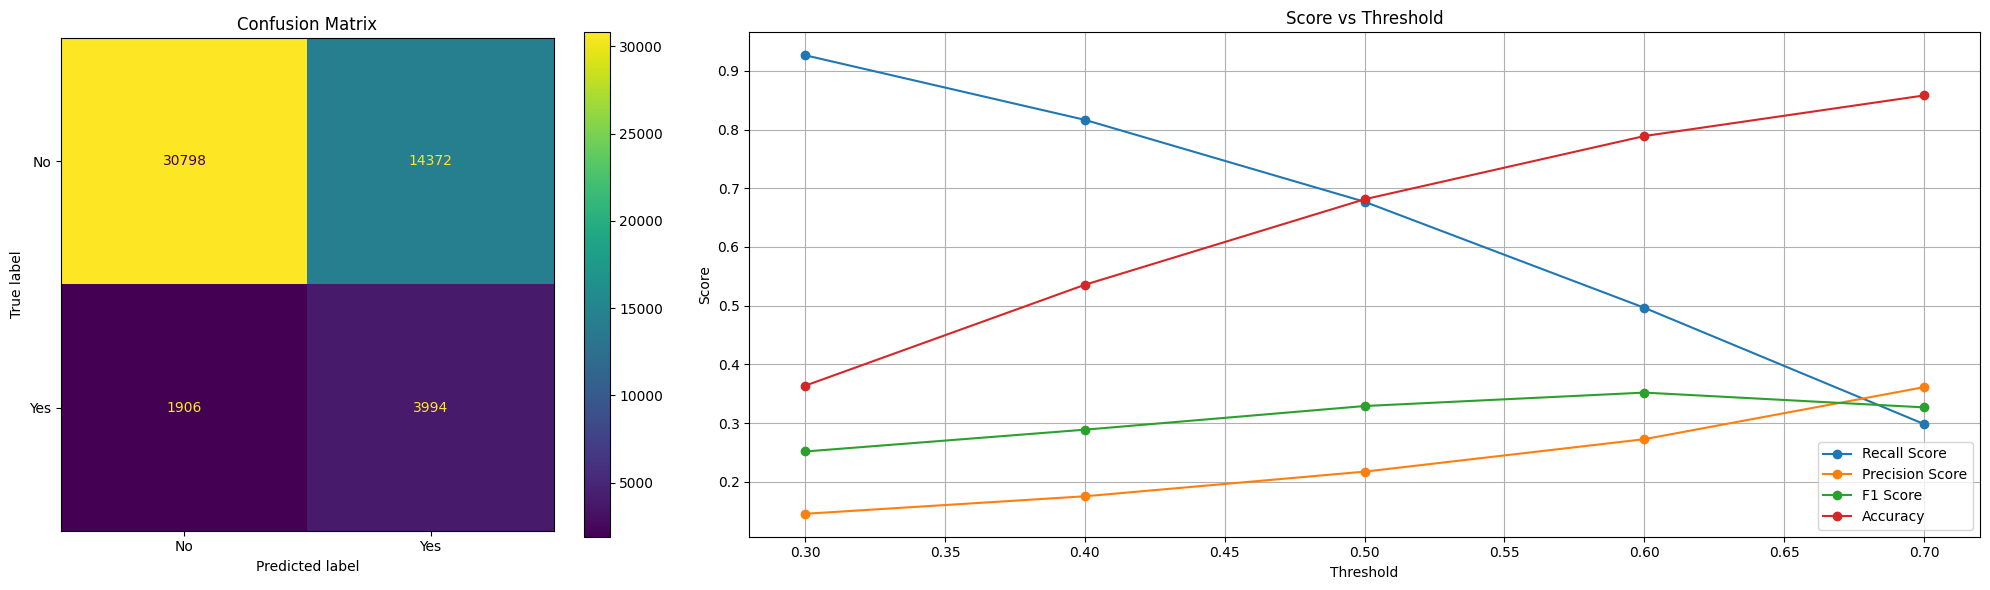

,Score,Percentage
0,Training Accuracy,74.83%
1,Test Accuracy,68.13%
2,Recall Score,67.69%
3,Precision Score,21.75%
4,Accuracy Score,68.13%
5,F1 Score,32.92%
6,ROC AUC Score,67.94%


In [58]:
scores_df, threshold_df = print_evaluation(soft_voter, X_train, y_train, X_test, y_test)
scores_df

In [59]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.926,0.146,0.252,0.364
0.400,0.816,0.176,0.289,0.536
0.500,0.677,0.217,0.329,0.681
0.600,0.496,0.273,0.352,0.789
0.700,0.298,0.361,0.327,0.858
